# MNIST

In [1]:
import sys
import torch
from torch.utils.tensorboard import SummaryWriter

from utils.checkpoint import load_checkpoint
from utils.data import get_dataloaders

sys.path.append("..")

from models.lenet import Net
from config import Config


In [30]:
%cd ./notebooks

/home/qosquo/dev/python/bayes_nn/notebooks


In [38]:
config = Config()
device = config.device

writer = SummaryWriter(log_dir="../runs/mnist_bayesian_lenet")

# Prepare data
_, test_loader = get_dataloaders(
    data_dir="../data",
    batch_size=config.test_batch_size,
    num_workers=config.num_workers,
    use_cuda=torch.cuda.is_available(),
)

# Model
model = Net(
    prior_sigma1=config.prior_sigma1,
    prior_sigma2=config.prior_sigma2,
    prior_pi=config.prior_pi,
    num_classes=config.num_classes,
).to(device)

# Optimizer (needed to load checkpoint)
optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)

# Load weights
config.model_name = 'mnist_bayesian_lenet_20251201'
epoch = load_checkpoint(model, optimizer, config.checkpoint_path, device)


[checkpoint] Loaded from ../checkpoints/mnist_bayesian_lenet_20251201.pth, starting at epoch 477


In [32]:
from evaluate import evaluate, evaluate_with_uncertainty
evaluate(model, test_loader, device)
evaluate_with_uncertainty(model, test_loader, device, mc_samples=5)

Accuracy: 97.42%
Predictions: [7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0]
Aleatoric: 0.03226979821920395
Epistemic: 0.025107720866799355


(tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0]),
 (tensor([[[ 5.0686e-06, -6.1127e-10, -3.2030e-10,  ..., -5.0652e-06,
            -3.7123e-12, -1.2349e-09],
           [-6.1127e-10,  1.2058e-04, -7.6210e-09,  ..., -1.2052e-04,
            -8.8328e-11, -2.9383e-08],
           [-3.2030e-10, -7.6210e-09,  6.3189e-05,  ..., -6.3151e-05,
            -4.6284e-11, -1.5396e-08],
           ...,
           [-5.0652e-06, -1.2052e-04, -6.3151e-05,  ...,  6.6438e-04,
            -7.3193e-07, -2.4348e-04],
           [-3.7123e-12, -8.8328e-11, -4.6284e-11,  ..., -7.3193e-07,
             7.3242e-07, -1.7844e-10],
           [-1.2349e-09, -2.9383e-08, -1.5396e-08,  ..., -2.4348e-04,
            -1.7844e-10,  2.4358e-04]],
  
          [[ 7.4280e-04, -3.6306e-06, -7.3885e-04,  ..., -3.5165e-08,
            -5.2904e-08, -1.4120e-10],
           [-3.6306e-06,  4.8602e-03, -4.8544e-03,  ..., -2.3104e-07,
            -3.4759e-07, -9.2774e-10],
           [-7.3885e-04, -4.8544e-03,  6.0265e-03,  ...

In [33]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

test_dataset = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=transform,
)
whole_loader = torch.utils.data.DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

output, uncertainties = evaluate_with_uncertainty(model, test_loader, device, mc_samples=5)

Predictions: [7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0]
Aleatoric: 0.0278385728597641
Epistemic: 0.00809025950729847


### Images

torch.Size([1, 28, 28])


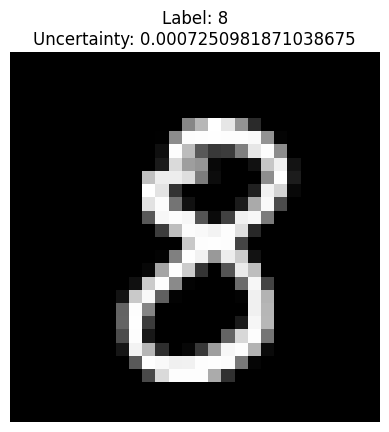

In [34]:
from utils.uncertainty import quantify_uncertainties
import matplotlib.pyplot as plt
from itertools import islice

# Get the i-th batch using islice
i = 665
data, target = next(islice(test_loader, i, i+1))
output, uncertainties = quantify_uncertainties(model, data, T=2)
# Get first image from batch
ind = 12
img = data[ind]
print(img.shape)

plt.imshow(img.squeeze(), cmap='gray')
plt.title(f'Label: {target[ind].item()}\nUncertainty: {uncertainties[1].diagonal(dim1=1, dim2=2).sum(-1)[ind]}')
plt.axis('off')
plt.show()

In [35]:
def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    """
    Add salt and pepper noise to an image
    Args:
        image: torch tensor of shape (1, 28, 28) for MNIST
        salt_prob: probability of salt noise (white pixels)
        pepper_prob: probability of pepper noise (black pixels)
    """
    noisy_image = image.clone()
    
    # Create random mask for salt noise
    salt_mask = torch.rand_like(image) < salt_prob
    # Create random mask for pepper noise  
    pepper_mask = torch.rand_like(image) < pepper_prob
    
    # Apply salt noise (set to 1)
    noisy_image[salt_mask] = 1.0
    # Apply pepper noise (set to 0)
    noisy_image[pepper_mask] = 0.0
    
    return noisy_image

def add_salt_pepper_noise_normalized(image, salt_prob=0.05, pepper_prob=0.05, data_mean=0.1307, data_std=0.3081):
    """
    Add salt and pepper noise to a NORMALIZED MNIST image
    """
    noisy_image = image.clone()
    
    # Calculate normalized values for min (0) and max (1)
    normalized_min = (0.0 - data_mean) / data_std  # ≈ -0.424
    normalized_max = (1.0 - data_mean) / data_std  # ≈ 2.823
    
    # Create random masks
    salt_mask = torch.rand_like(image) < salt_prob
    pepper_mask = torch.rand_like(image) < pepper_prob
    
    # Apply salt noise (set to normalized max)
    noisy_image[salt_mask] = normalized_max
    # Apply pepper noise (set to normalized min)  
    noisy_image[pepper_mask] = normalized_min
    
    return noisy_image

In [ ]:
def display_images_with_uncertainty(model, test_loader, batch_idx=0, img_idx=0, salt_prob=0.05, pepper_prob=0.05, T=5):
    # Get the i-th batch using islice
    data, target = next(islice(test_loader, batch_idx, batch_idx+1))
    output, uncertainties = quantify_uncertainties(model, data, T)

    # Get first image from batch
    img = data[img_idx]

    # Add salt and pepper noise to the image
    noisy_img = add_salt_pepper_noise_normalized(img, salt_prob=salt_prob, pepper_prob=pepper_prob)

    # Create subplots to compare original and noisy images
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Plot original image
    ax1.imshow(img.squeeze(), cmap='gray')
    # ax1.set_title(f'Original\nLabel: {target[img_idx].item()}')
    ax1.set_title(f"""
Original
Original uncertainty: {uncertainties[1].diagonal(dim1=1, dim2=2).sum(-1)[img_idx]:.6f}
Original correct: {output[img_idx].item() == target[img_idx].item()} ({output[img_idx].item()})
    """)
    ax1.axis('off')

    # You can also quantify uncertainties for the noisy image
    noisy_data = noisy_img.unsqueeze(0)  # Add batch dimension
    noisy_output, noisy_uncertainties = quantify_uncertainties(model, noisy_data, T)
    # Plot noisy image
    ax2.imshow(noisy_img.squeeze(), cmap='gray')
    ax2.set_title(f"""
Noisy
Noisy uncertainty: {noisy_uncertainties[1].diagonal(dim1=1, dim2=2).sum(-1)[0]:.6f}
Noisy correct: {noisy_output[0].item() == target[img_idx].item()} ({noisy_output[0].item()})
    """)
    ax2.axis('off')

    plt.suptitle(f"Label: {target[img_idx].item()}")
    plt.tight_layout()
    plt.show()

    writer.add_figure(f"img[{batch_idx}][{img_idx}]_{salt_prob}-{pepper_prob}", fig, 0)


    print(f"Original uncertainty: {uncertainties[1].diagonal(dim1=1, dim2=2).sum(-1)[img_idx]}")
    print(f"Original correct: {output[img_idx].item() == target[img_idx].item()} ({output[img_idx].item()})")
    print(f"Noisy uncertainty: {noisy_uncertainties[1].diagonal(dim1=1, dim2=2).sum(-1)[0]}")
    print(f"Noisy correct: {noisy_output[0].item() == target[img_idx].item()} ({noisy_output[0].item()})")

### Цифра 3


AttributeError: module 'matplotlib.pyplot' has no attribute 'set_title'

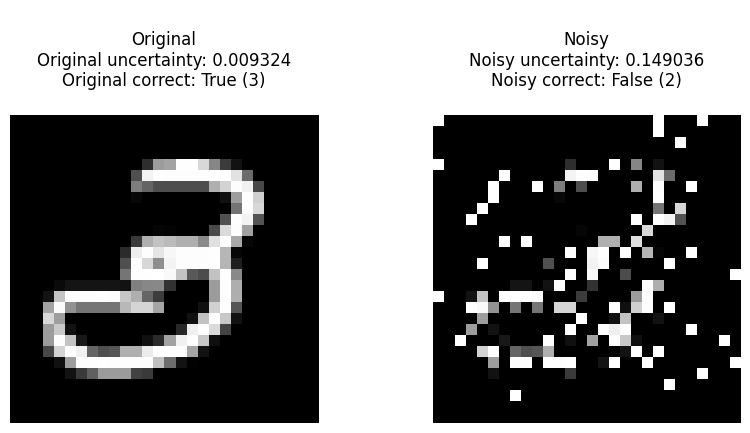

In [77]:
display_images_with_uncertainty(model, test_loader, batch_idx=695, img_idx=12, salt_prob=0.1, pepper_prob=0.5, T=15)

### Цифра 9


In [ ]:
display_images_with_uncertainty(model, test_loader, batch_idx=688, img_idx=10, salt_prob=0.05, pepper_prob=0.3, T=15)

In [ ]:
display_images_with_uncertainty(model, test_loader, batch_idx=688, img_idx=10, salt_prob=0.1, pepper_prob=0.01, T=15)

In [ ]:
display_images_with_uncertainty(model, test_loader, batch_idx=290, img_idx=5, salt_prob=0.03, pepper_prob=0.1, T=15)

In [ ]:
import random
rand_batch_idx = random.randint(0, len(test_loader)-1)
rand_img_idx = random.randint(0, test_batch_size-1)
print(f"Random batch index: {rand_batch_idx}, image index: {rand_img_idx}")
display_images_with_uncertainty(model, test_loader, batch_idx=rand_batch_idx, img_idx=rand_img_idx, salt_prob=0.05, pepper_prob=0.01, T=15)

## Display convolution layers

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def visualize_conv_activations(model, data, layer_names=None):
    """Visualize activations of convolutional layers"""
    model.eval()
    with torch.no_grad():
        x = data.unsqueeze(0).to(device)  # Add batch dimension
        
        # Dictionary to store activations
        activations = {}
        
        # Forward pass with activation capture
        # Layer 1
        x = F.tanh(model.conv1(x))
        activations['conv1'] = x.cpu().numpy()
        
        x = model.pool1(x)
        
        # Layer 2
        x = F.tanh(model.conv2(x))
        activations['conv2'] = x.cpu().numpy()
        
    # Visualize activations
    for layer_name, act in activations.items():
        if layer_names and layer_name not in layer_names:
            continue
            
        batch_size, channels, height, width = act.shape
        
        # Create a grid for visualization
        if layer_name == 'conv1':
            # For conv1 with 6 channels, create a 2x3 grid
            rows, cols = 2, 3
        elif layer_name == 'conv2':
            # For conv2 with 16 channels, create a 4x4 grid
            rows, cols = 4, 4
        else:
            # Default behavior
            rows, cols = 1, channels
            
        fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 2*rows), squeeze=False)
        
        # Flatten the activations array for easy indexing
        activation_maps = act[0]  # Shape: (channels, height, width)
        
        # Display each activation map in the grid
        for i in range(channels):
            row = i // cols
            col = i % cols
            axes[row, col].imshow(activation_maps[i], cmap='viridis')
            axes[row, col].set_title(f'{layer_name} Ch {i+1}')
            axes[row, col].axis('off')
        
        # Hide empty subplots if there are any
        total_subplots = rows * cols
        for i in range(channels, total_subplots):
            row = i // cols
            col = i % cols
            axes[row, col].axis('off')
        
        plt.suptitle(f'{layer_name} Activations')
        plt.tight_layout()
        plt.show()
    
    return activations

# Get a sample from test set
for data, target in test_loader:
    sample_data = data[0]  # First image in batch
    sample_data = add_salt_pepper_noise_normalized(sample_data, salt_prob=0.1, pepper_prob=0.01)
    plt.imshow(sample_data.squeeze(), cmap='gray')
    sample_target = target[0]
    break

# Visualize activations for the sample
print("\nVisualizing Convolutional Activations:")
activations = visualize_conv_activations(model, sample_data)

# Display the original image for reference
plt.figure(figsize=(4, 4))
plt.imshow(sample_data.squeeze(), cmap='gray')
plt.title(f'Original Image - Label: {sample_target.item()}')
plt.axis('off')
plt.show()
